# What Do 383,000 Financial Complaints Reveal?
**LDA Topic Modeling · TF-IDF · VADER · Logistic Regression · Word2Vec · Zero-Shot (BART-MNLI) · spaCy NER**

Every year, millions of Americans file complaints against banks, lenders, and credit bureaus with the CFPB. The richest signal sits in the free-text narratives no one reads systematically. This project mines that text with an end-to-end NLP pipeline, turning an unreadable pile of complaints into something a regulator could triage and act on.

**Research questions:**
- What are people actually complaining about, and which themes dominate the corpus?
- Can complaint text predict which complaints are at risk of an untimely company response?
- Does complaint tone vary systematically by financial product?

## 1. Setup
Load the libraries for data handling, NLP, modeling, and plotting, and set global options.

In [1]:
!pip install -q gensim transformers
!python -m spacy download en_core_web_sm

import os, re, warnings
import numpy as np
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display

import gdown

import nltk
nltk.download('stopwords')
nltk.download('vader_lexicon')
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, recall_score, precision_score, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.utils import resample

from transformers import pipeline, BartForConditionalGeneration, BartTokenizer

from collections import Counter

import torch

import pickle

from wordcloud import WordCloud

warnings.filterwarnings('ignore')

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print('Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 32.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Setup complete.


## 2. Style and Helper Functions
Define one plot style and a few reusable helpers so every chart shares the same look and the code below stays clean.

In [2]:
LIME  = "#c8ff00"
PINK  = "#ff69b4"
WHITE = "#ffffff"
BG    = "#0a0a0a"
GRAY  = "#333333"
MGRAY = "#1a1a1a"

sns.set_style("dark", {"axes.facecolor": BG, "figure.facecolor": BG})

plt.rcParams.update({
    "figure.figsize":    (10, 6),
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    GRAY,
    "axes.labelcolor":   WHITE,
    "xtick.color":       WHITE,
    "ytick.color":       WHITE,
    "text.color":        WHITE,
    "axes.titleweight":  "bold",
    "axes.titlesize":    14,
    "axes.labelsize":    11,
    "legend.facecolor":  BG,
    "legend.edgecolor":  GRAY,
    "legend.labelcolor": WHITE,
})

def apply_style(ax):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.grid(True, axis="y", color=MGRAY, linewidth=0.8)
    ax.grid(False, axis="x")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(GRAY)
    ax.spines["bottom"].set_color(GRAY)

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close()

print('Style and helpers ready.')

Style and helpers ready.


## 3. Load the Data
Pull in the CFPB Consumer Complaint Database (1,282,355 complaints, March 2015–March 2019) and take a first look — size, columns, data types, and missing values — before touching anything.

In [3]:
FILE_ID = '1zz2fjy1dCNrsppbSuuna8CccRI8Ima-7'
OUTPUT = 'cfpb_complaints.csv'

if not os.path.exists(OUTPUT):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUTPUT, quiet=False, fuzzy=True)

df = pd.read_csv(OUTPUT)
pd.set_option('display.max_columns', None)

print('=' * 60)
print('RAW DATASET OVERVIEW')
print('=' * 60)
print('Source:', OUTPUT)
print(f'Shape: {df.shape[0]:,} complaints, {df.shape[1]} columns\n')

# preview the data
display(df.head())

# column data types
print('\nData types:')
print(df.dtypes)

# missing values per column
print('\nMissing values (only columns with gaps shown):')
missing = df.isnull().sum()
print(missing[missing > 0])

# summary statistics — text/categorical columns get skipped here, which is itself a red flag
print('\nSummary statistics:')
display(df.describe())

# timely response balance — this is the target class for the late-response classifier
print('\nTimely response balance:')
print(df['Timely response?'].value_counts(normalize=True).round(3))

Downloading...
From (original): https://drive.google.com/uc?id=1zz2fjy1dCNrsppbSuuna8CccRI8Ima-7
From (redirected): https://drive.google.com/uc?id=1zz2fjy1dCNrsppbSuuna8CccRI8Ima-7&confirm=t&uuid=9857ef25-235e-4369-ad16-070f2eeb63bc
To: /content/cfpb_complaints.csv
100%|██████████| 737M/737M [00:07<00:00, 93.5MB/s]


RAW DATASET OVERVIEW
Source: cfpb_complaints.csv
Shape: 1,282,355 complaints, 18 columns



,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460



Data types:
Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object

Missing values (only columns with gaps shown):
Sub-product                      235166
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
State                             19400
ZIP code               

,Complaint ID
count,1.282355e+06
mean,1.929831e+06
std,9.645326e+05
min,1.000000e+00
25%,1.124152e+06
50%,2.123218e+06
75%,2.798886e+06
max,3.238682e+06



Timely response balance:
Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64


Two things stand out immediately: only about 30% (383,564) of complaints include a written narrative — the rest are structured-only — and the target, *Timely response?*, is severely imbalanced at roughly 97% Yes / 3% No. Both shape every decision that follows.

## 4. Clean and Prepare the Data
The raw file has 18 columns but only 10 are tied to the three research questions, and 898,791 rows have no narrative text to analyze. I trim to the relevant columns, drop the narrative-less rows, parse the date, and add a word-count column. I then build a cleaned text field for modeling — keeping both the raw and cleaned narrative, since most methods use the clean version but VADER sentiment needs the raw one.

In [4]:
raw_count = len(df)
raw_cols = df.shape[1]

# select and rename to snake_case
cols = {
    'Consumer complaint narrative': 'narrative',
    'Product': 'product',
    'Sub-product': 'sub_product',
    'Issue': 'issue',
    'Sub-issue': 'sub_issue',
    'Timely response?': 'timely_response',
    'Company': 'company',
    'State': 'state',
    'Submitted via': 'submitted_via',
    'Date received': 'date_received',
}
df = df[list(cols)].rename(columns=cols)

# drop no-narrative rows
df = df.dropna(subset=['narrative']).reset_index(drop=True)

# parse date -> year, add word count
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
df['year'] = df['date_received'].dt.year
df['narrative_length'] = df['narrative'].str.split().str.len()

# clean text -> clean_narrative
stop_words = set(stopwords.words('english'))
stop_words |= {'account', 'bank', 'company', 'xxxx', 'xx'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'x{2,}', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_narrative'] = df['narrative'].apply(clean_text)

print('=' * 60)
print('DATA CLEANING SUMMARY')
print('=' * 60)
print(f'Raw dataset:   {raw_count:,} complaints, {raw_cols} columns')
print(f'Dropped {raw_count - len(df):,} rows with no narrative')
print(f'Clean dataset: {len(df):,} complaints, {df.shape[1]} columns')
print('Parsed date -> year; added narrative_length and clean_narrative\n')
print('First few rows (raw vs cleaned):')
df[['narrative', 'clean_narrative']].head(3)

DATA CLEANING SUMMARY
Raw dataset:   1,282,355 complaints, 18 columns
Dropped 898,791 rows with no narrative
Clean dataset: 383,564 complaints, 13 columns
Parsed date -> year; added narrative_length and clean_narrative

First few rows (raw vs cleaned):


,narrative,clean_narrative
0,The Summer of XX/XX/2018 I was denied a mortga...,summer denied mortgage loan due charge credit ...
1,There are many mistakes appear in my report wi...,many mistakes appear report without understanding
2,There are many mistakes appear in my report wi...,many mistakes appear report without understanding


## 5. Explore: How Long Are Complaints, and When Did They Spike?

Before modeling the text, I check what I'm actually working with. Complaint narratives vary widely in length — some are a sentence, others run thousands of words — which matters for how much signal each one carries for topic modeling and TF-IDF weighting. I also plot complaint volume over time to see whether the data is spread evenly across 2015–2019 or concentrated in certain periods, since a lopsided volume trend affects how I interpret topic and sentiment patterns later and how I set up the time-ordered split for the classifier.

Total narratives:     383,564
Avg words/complaint:  196.8
Median word count:    136
Max word count:       6,314


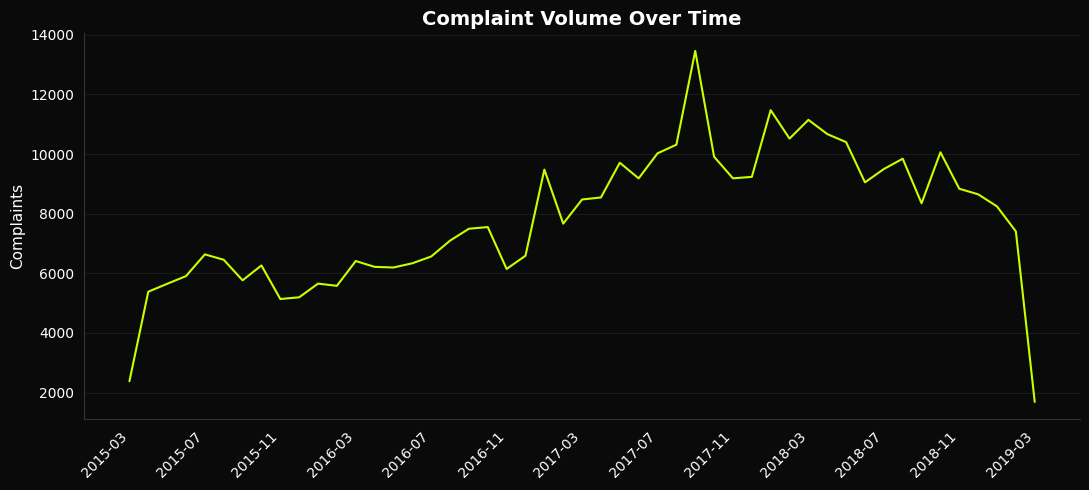


Last complaint date in dataset: 2019-03-23 00:00:00

Complaints per month, last 3 months:
date_received
2019-01    8242
2019-02    7404
2019-03    1686
Freq: M, dtype: int64


In [5]:
# narrative length distribution
print(f"Total narratives:     {len(df):,}")
print(f"Avg words/complaint:  {df['narrative_length'].mean():.1f}")
print(f"Median word count:    {df['narrative_length'].median():.0f}")
print(f"Max word count:       {df['narrative_length'].max():,}")

# complaint volume over time
vol = df.groupby(df['date_received'].dt.to_period('M')).size()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(vol)), vol.values, color=LIME)
ax.set_title('Complaint Volume Over Time'); ax.set_ylabel('Complaints')
ax.set_xticks(range(0, len(vol), max(1, len(vol)//12)))
ax.set_xticklabels([str(vol.index[i]) for i in range(0, len(vol), max(1, len(vol)//12))], rotation=45, ha='right')
apply_style(ax)
save_plot('volume_over_time.png')

# confirm the sharp drop in the final month is a partial-data artifact, not a real decline
print('\nLast complaint date in dataset:', df['date_received'].max())
print('\nComplaints per month, last 3 months:')
print(df.groupby(df['date_received'].dt.to_period('M')).size().tail(3))

**Takeaway:** The average complaint runs 196.8 words, but the median is just 136 — the same right-skew pattern as Spotify's streams distribution, with a handful of complaints running as long as 6,314 words pulling the average above the typical case. Across all 383,564 narratives, that spread matters for modeling: treating every complaint as equivalent length would understate how much signal the longer ones carry for TF-IDF and topic modeling. Complaint volume climbs steadily from 2015 into a peak around late 2017, dips and recovers through 2018, then tapers off; the final data point reflects a partial last month rather than a genuine drop in complaints. The steady rise over the window is part of why a time-ordered split makes sense for the classifier later, rather than a random one.

## 6. What Are People Complaining About?
The richest signal is in the free text, so I work up from simple word counts to full topic modeling — each method a sharper lens on the same question.

### Most frequent vocabulary
Before any modeling, I start simple: count the words. This is both a first look at what dominates the complaints and a data-quality check — if the cleaned text follows Zipf's Law (a few words very common, most rare), it's behaving like natural language and the preprocessing didn't corrupt it. From there I build up: a word cloud for a quick visual, TF-IDF to pull each product's signature terms, and n-grams to catch the common multi-word phrases.

Top 20 words:
  credit          586,079
  would           262,840
  payment         256,860
  loan            251,330
  report          248,600
  information     234,015
  debt            207,420
  told            200,382
  received        185,871
  time            167,798
  called          162,944
  card            162,639
  never           153,835
  payments        148,748
  sent            144,049
  letter          138,040
  pay             137,917
  back            134,031
  mortgage        131,869
  get             130,028

Top 10 words = 8.3% of all tokens


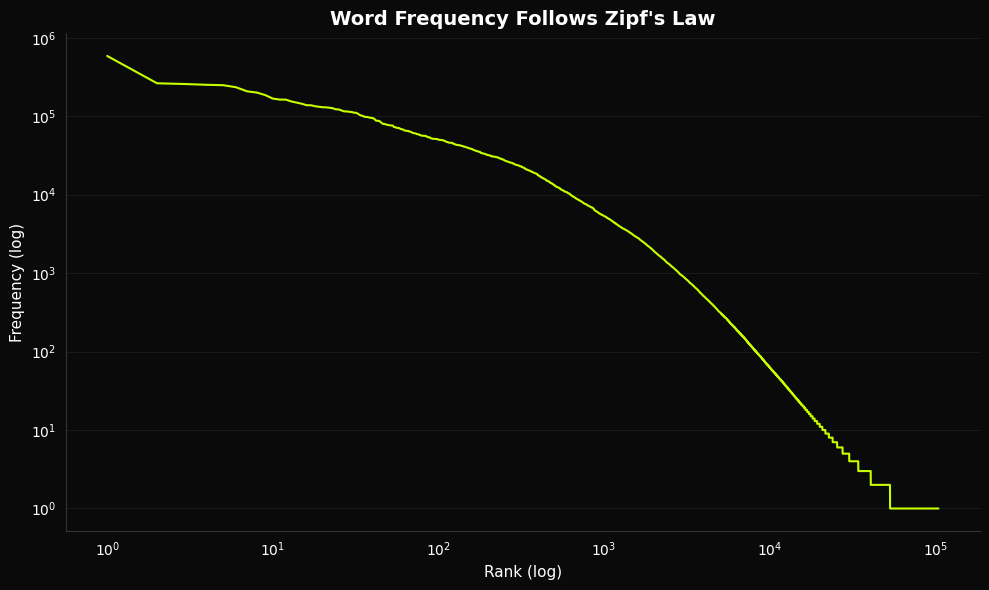

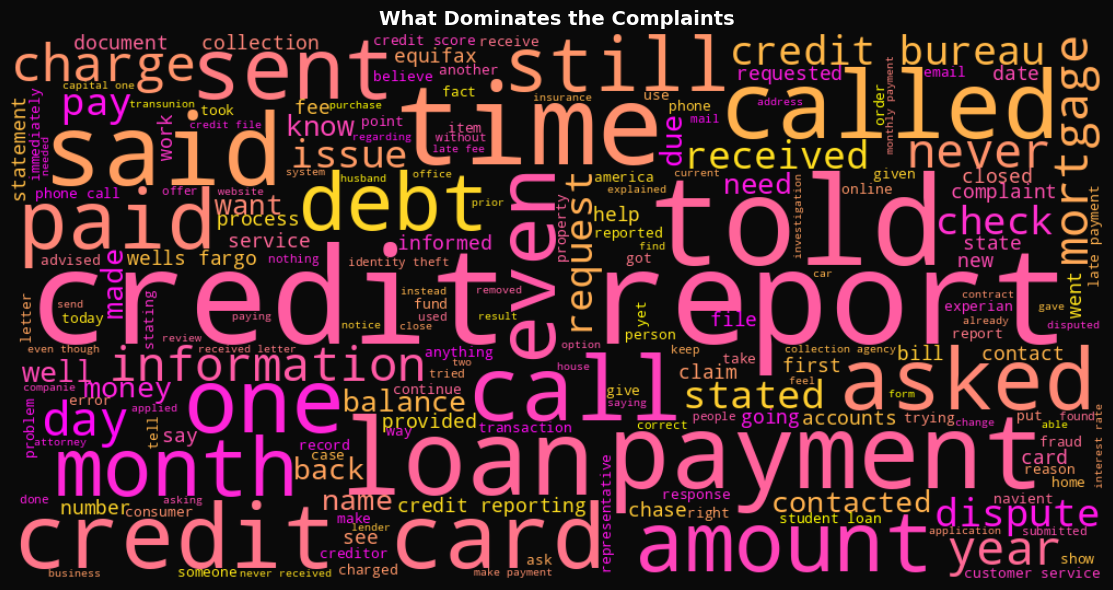

Most distinctive terms by product:

Credit reporting, credit repair services, or other personal consumer reports:
   credit, report, information, reporting, accounts, equifax, payment, would

Debt collection:
   debt, credit, collection, report, received, information, would, call

Mortgage:
   loan, mortgage, payment, would, home, payments, told, received

Top Bigrams:
   credit report                18,681
   credit card                  8,822
   wells fargo                  5,881
   credit reporting             4,925
   credit bureaus               4,536
   customer service             4,232
   credit score                 3,608
   identity theft               3,269
   collection agency            3,233
   credit reports               3,178

Top Trigrams:
   credit reporting agencies    1,525
   fair credit reporting        1,519
   credit reporting act         1,488
   social security number       1,232
   removed credit report        1,013
   victim identity theft        946
   con

In [6]:
# word frequency across all cleaned narratives
all_words = ' '.join(df['clean_narrative']).split()
word_counts = Counter(all_words)
print('Top 20 words:')
for w, c in word_counts.most_common(20):
    print(f'  {w:15s} {c:,}')
top10_share = sum(c for _, c in word_counts.most_common(10)) / len(all_words)
print(f'\nTop 10 words = {top10_share:.1%} of all tokens')

# Zipf's Law: frequency vs rank (log-log)
freqs = sorted(word_counts.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)
fig, ax = plt.subplots()
ax.loglog(ranks, freqs, color=LIME)
ax.set_title("Word Frequency Follows Zipf's Law")
ax.set_xlabel('Rank (log)'); ax.set_ylabel('Frequency (log)')
apply_style(ax)
save_plot('zipf.png')

# word cloud (10K sample)
sample_text = ' '.join(df['clean_narrative'].sample(10000, random_state=42))
wc = WordCloud(width=1000, height=500, background_color=BG, colormap='spring').generate(sample_text)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('What Dominates the Complaints')
save_plot('wordcloud.png')

# TF-IDF: most distinctive words per top-3 product
top_products = df['product'].value_counts().head(3).index.tolist()
docs = [' '.join(df.loc[df['product'] == p, 'clean_narrative'].sample(min(20000, (df['product'] == p).sum()), random_state=42))
        for p in top_products]
tfidf = TfidfVectorizer(max_features=3000)
matrix = tfidf.fit_transform(docs)
terms = tfidf.get_feature_names_out()
print('Most distinctive terms by product:\n')
for i, prod in enumerate(top_products):
    row = matrix[i].toarray().ravel()
    print(f'{prod}:\n   {", ".join(terms[j] for j in row.argsort()[::-1][:8])}\n')

# top bigrams and trigrams (50K sample)
sample = df['clean_narrative'].sample(50000, random_state=42)
for n, label in [(2, 'Bigrams'), (3, 'Trigrams')]:
    cv = CountVectorizer(ngram_range=(n, n), max_features=10)
    m = cv.fit_transform(sample)
    counts = m.sum(axis=0).A1
    grams = cv.get_feature_names_out()
    print(f'Top {label}:')
    for t, c in sorted(zip(grams, counts), key=lambda x: -x[1]):
        print(f'   {t:28s} {c:,}')
    print()

**Takeaway:** The frequency curve follows Zipf's Law, confirming the cleaned text behaves like natural language and the preprocessing didn't corrupt it. The products share a core vocabulary (*credit, report, payment*), but each carries distinctive markers — credit reporting leans on *reporting, accounts, Equifax*; debt collection on *collection, call*; mortgage on *mortgage, home, loan*. The bigrams sharpen it further (*credit report, collection agency, identity theft, Wells Fargo*). Complaints carry product-specific language a model could route on — but word counts only show *which words* appear, not the themes tying them together, so next I let a topic model surface those.

### Topics uncovered by LDA
Word counts show *which* words appear, not the themes behind them. LDA (Latent Dirichlet Allocation) is an unsupervised topic model — with no labels, it finds themes by spotting words that co-occur, treating each complaint as a mix of topics. I run it on a 30K sample, set to 8 topics, then read each word group and hand-label it.

8 LDA topics (top words):

Topic 1: debt, collection, received, letter, collect, agency, court, never, owe, amount
Topic 2: information, credit, consumer, report, equifax, address, identity, name, security, number
Topic 3: payment, mortgage, loan, payments, received, would, sent, insurance, told, due
Topic 4: credit, report, information, letter, accounts, sent, reporting, dispute, inquiry, proof
Topic 5: credit, report, reporting, reported, late, removed, information, paid, score, balance
Topic 6: told, called, would, call, card, said, back, money, phone, check
Topic 7: loan, chase, home, wells, fargo, mortgage, modification, property, sale, foreclosure
Topic 8: loan, payment, payments, would, pay, interest, credit, loans, card, time


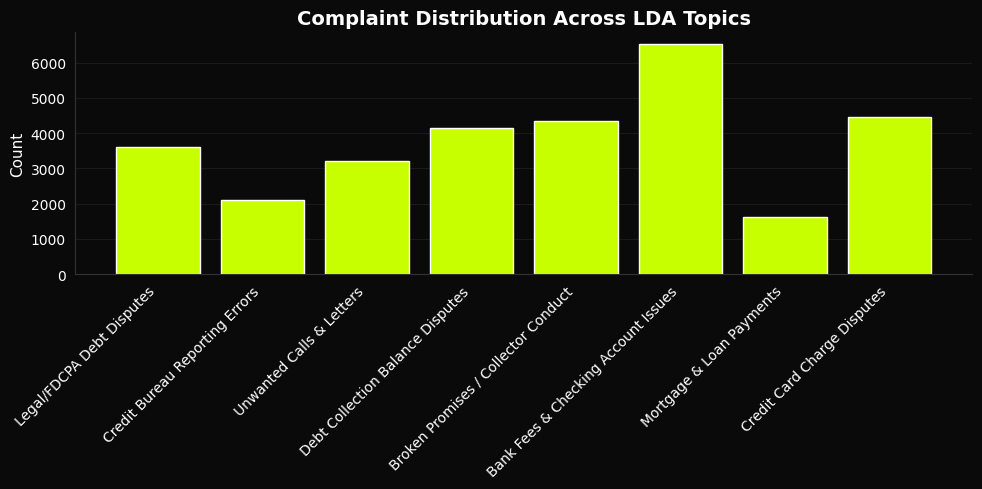

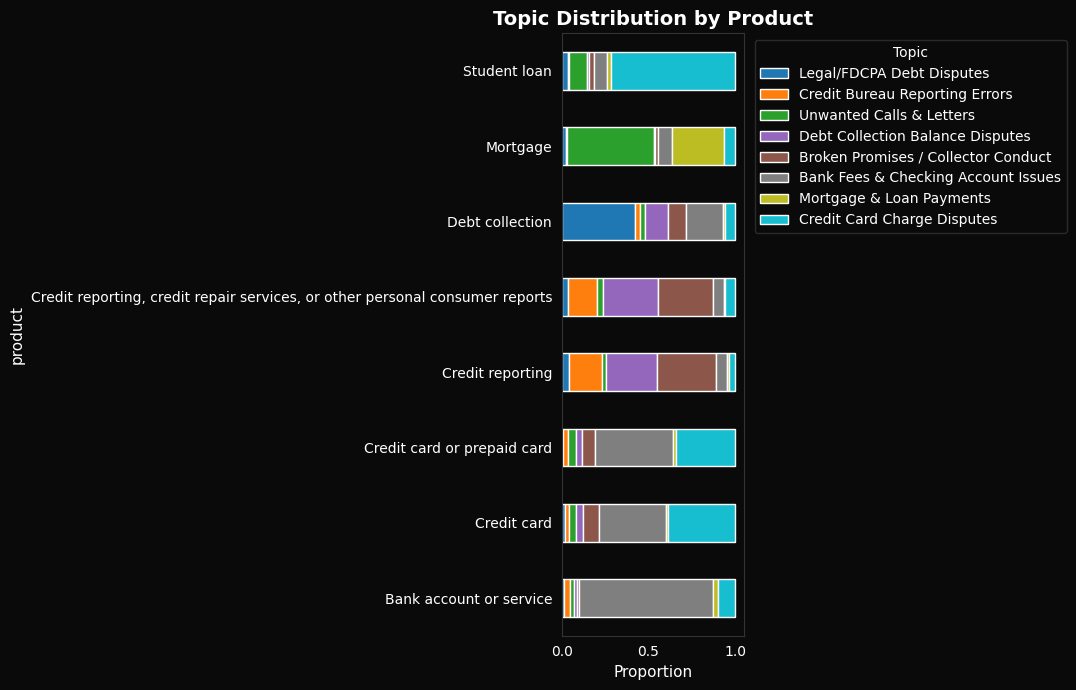

In [7]:
# LDA on a 30K sample, 8 topics
lda_sample = df['clean_narrative'].sample(30000, random_state=42)

count_vec = CountVectorizer(max_features=1000, min_df=5, max_df=0.9)
dtm = count_vec.fit_transform(lda_sample)

lda = LatentDirichletAllocation(n_components=8, random_state=42, max_iter=10)
lda.fit(dtm)

vocab = count_vec.get_feature_names_out()
print('8 LDA topics (top words):\n')
for i, topic in enumerate(lda.components_):
    top_words = [vocab[j] for j in topic.argsort()[::-1][:10]]
    print(f'Topic {i+1}: {", ".join(top_words)}')

# assign each complaint its dominant topic — reuse lda_sample's exact index so this
# is guaranteed to be the same 30K rows the LDA model was fit on
lda_df = df.loc[lda_sample.index].copy()
lda_df['topic'] = lda.transform(count_vec.transform(lda_df['clean_narrative'])).argmax(axis=1)

# human-readable names based on each topic's top words
topic_names = {
    0: 'Legal/FDCPA Debt Disputes',
    1: 'Credit Bureau Reporting Errors',
    2: 'Unwanted Calls & Letters',
    3: 'Debt Collection Balance Disputes',
    4: 'Broken Promises / Collector Conduct',
    5: 'Bank Fees & Checking Account Issues',
    6: 'Mortgage & Loan Payments',
    7: 'Credit Card Charge Disputes',
}

# complaints per topic
counts = lda_df['topic'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([topic_names[i] for i in counts.index], counts.values, color=LIME)
ax.set_title('Complaint Distribution Across LDA Topics'); ax.set_ylabel('Count')
apply_style(ax); plt.xticks(rotation=45, ha='right')
save_plot('topic_distribution.png')

# topic mix by product (top 8 products)
top_prods = lda_df['product'].value_counts().head(8).index
ct = pd.crosstab(lda_df[lda_df['product'].isin(top_prods)]['product'],
                  lda_df[lda_df['product'].isin(top_prods)]['topic'], normalize='index')

# rename columns 0-7 -> named topics so the legend matches the first chart
ct.columns = [topic_names[i] for i in ct.columns]

ct.plot(kind='barh', stacked=True, figsize=(11, 7), colormap='tab10')
plt.title('Topic Distribution by Product'); plt.xlabel('Proportion')
plt.legend(title='Topic', bbox_to_anchor=(1.02, 1))
save_plot('topic_by_product.png')

**Takeaway:** LDA surfaced 8 coherent themes, which I hand-labeled from their top words:
1. **Legal/FDCPA Debt Disputes** — letters, court, law, attorney
2. **Credit Bureau Reporting Errors** — Equifax, Experian, disputes, removals
3. **Unwanted Calls & Letters** — repeated correspondence and inquiries
4. **Debt Collection Balance Disputes** — collection agencies, disputed balances
5. **Broken Promises / Collector Conduct** — "told," calls, being given the runaround
6. **Bank Fees & Checking Account Issues** — checking, funds, fees
7. **Mortgage & Loan Payments** — payments, interest, home loans
8. **Credit Card Charge Disputes** — card charges, balances, issuers (Chase)

**Credit Bureau Reporting Errors is the single largest theme, with Mortgage & Loan Payments and Broken Promises / Collector Conduct also prominent.** The surprise: most of the largest themes are about *process* — disputes, calls, collection conduct — not the financial product itself. People complain about how they're treated, not the loan or card per se. This becomes the through-line for the rest of the analysis.

## 7. Does Complaint Tone Vary by Product? (VADER Sentiment)
VADER is a rule-based sentiment tool built for informal text — it scores tone from −1 (negative) to +1 (positive) using a word dictionary plus rules for negation, intensifiers, and ALL CAPS. I run it on the *raw* narrative (20K sample), not the cleaned one, because punctuation and capitalization carry the emotion. If some products run angrier or longer than others, that tells a regulator where to look.

Overall sentiment distribution:
sentiment_label
negative    0.505
positive    0.449
neutral     0.046
Name: proportion, dtype: float64 

Complaint volume by product (this 20K sample):
product
Credit reporting, credit repair services, or other personal consumer reports    4784
Debt collection                                                                 4598
Mortgage                                                                        2790
Credit reporting                                                                1654
Student loan                                                                    1205
Credit card or prepaid card                                                     1050
Credit card                                                                      930
Bank account or service                                                          755
Checking or savings account                                                      689
Consumer Loan                              

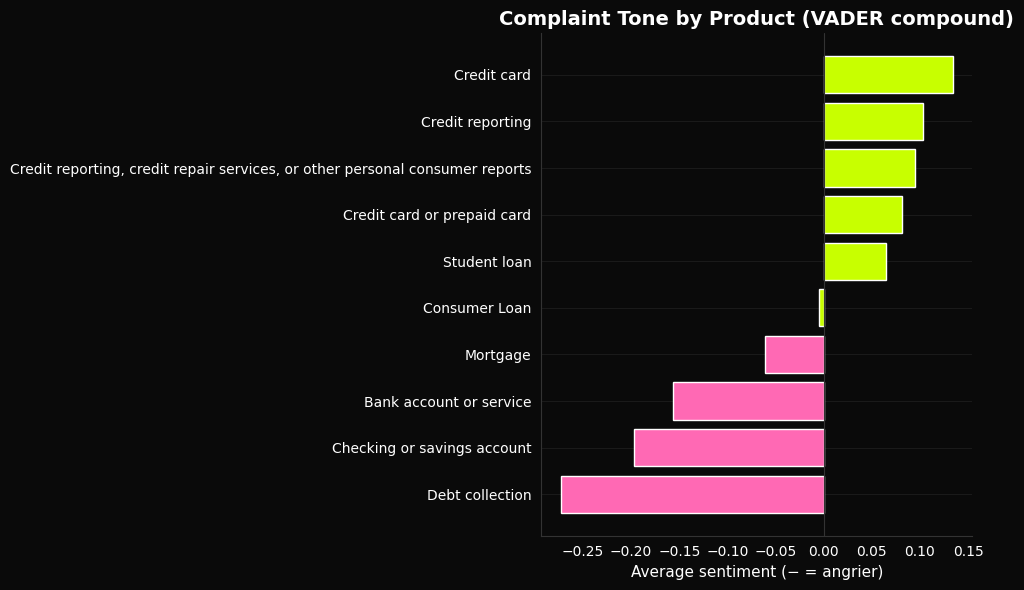


Most negative states (>=50 complaints):
state
NH   -0.230
AR   -0.167
IN   -0.162
DE   -0.137
IA   -0.130
Name: sentiment, dtype: float64

Sentiment by timely response:
timely_response
No    -0.153
Yes   -0.038
Name: sentiment, dtype: float64


In [8]:
sia = SentimentIntensityAnalyzer()
sent_sample = df.sample(20000, random_state=42).copy()
sent_sample['sentiment'] = sent_sample['narrative'].apply(lambda t: sia.polarity_scores(str(t))['compound'])

def label(s):
    if s > 0.05:  return 'positive'
    if s < -0.05: return 'negative'
    return 'neutral'
sent_sample['sentiment_label'] = sent_sample['sentiment'].apply(label)

print('Overall sentiment distribution:')
print(sent_sample['sentiment_label'].value_counts(normalize=True).round(3), '\n')

top10_products = sent_sample['product'].value_counts().head(10).index

# complaint volume by product — needed to confirm which category is actually highest-volume
print('Complaint volume by product (this 20K sample):')
print(sent_sample['product'].value_counts().head(10), '\n')

by_product = sent_sample[sent_sample['product'].isin(top10_products)].groupby('product')['sentiment'].mean().sort_values()
print('Avg sentiment by product (most to least negative):')
print(by_product.round(3), '\n')

len_by_product = (sent_sample[sent_sample['product'].isin(top10_products)]
                  .groupby('product')['narrative_length'].mean().sort_values(ascending=False))
print('Avg narrative length by product (words):')
print(len_by_product.round(0))

# chart: sentiment by product
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PINK if v < by_product.mean() else LIME for v in by_product]
ax.barh(by_product.index.astype(str), by_product.values, color=colors)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title('Complaint Tone by Product (VADER compound)')
ax.set_xlabel('Average sentiment (− = angrier)')
apply_style(ax)
save_plot('sentiment_by_product.png')

# most negative states (>=50 complaints, to reduce noise)
sc = sent_sample['state'].value_counts()
by_state = (sent_sample[sent_sample['state'].isin(sc[sc >= 50].index)]
            .groupby('state')['sentiment'].mean().sort_values())
print('\nMost negative states (>=50 complaints):')
print(by_state.head(5).round(3))

print('\nSentiment by timely response:')
print(sent_sample.groupby('timely_response')['sentiment'].mean().round(3))


**Takeaway:** Complaints are negative overall (about 51%), and the top two highest-volume categories sit at opposite emotional extremes. Credit reporting (the "credit reporting, credit repair services, or other personal consumer reports" category — the single highest-volume group at 4,784 complaints in this sample) runs calm, at +0.10 sentiment on a relatively short 151-word average narrative. Debt collection is a close second by volume (4,598 complaints) but by far the angriest category (−0.27). Mortgage complaints, by contrast, are the longest (279 words) and moderately negative (−0.06). Credit-reporting complaints read like short, formulaic dispute letters; debt-collection complaints are genuinely distressed, and mortgage complaints are long and complex. This complicates a clean "volume ≠ anger" story: the single largest category happens to be calm, but the second-largest is also the angriest — so a regulator can't treat high volume as a proxy for low urgency. Sentiment is also notably more negative for complaints that received an untimely response (−0.15 vs. −0.04, roughly 4x lower), and the angriest states (NH, AR, IN, DE, IA) are all lower-complaint-volume states, so some of that spread is noise even after filtering to states with 50+ complaints.

## 8. Who and What Do Complaints Mention? (spaCy NER)
Topic modeling gave me the themes; now I want the specific players. spaCy's named-entity recognition (NER) pulls real-world entities — here, the organizations named in complaints — from a 2K sample of the raw narratives. Who gets named most?

Most-named organizations:
  Equifax                181
  Chase                  155
  Bank of America        152
  CFPB                   140
  Wells Fargo            117
  American Express       113
  FCRA                   102
  Navient                70
  Citibank               63
  BOA                    45
  Capital One            43
  Borrower               37
  Trans Union            36
  USAA                   35
  FTC                    29


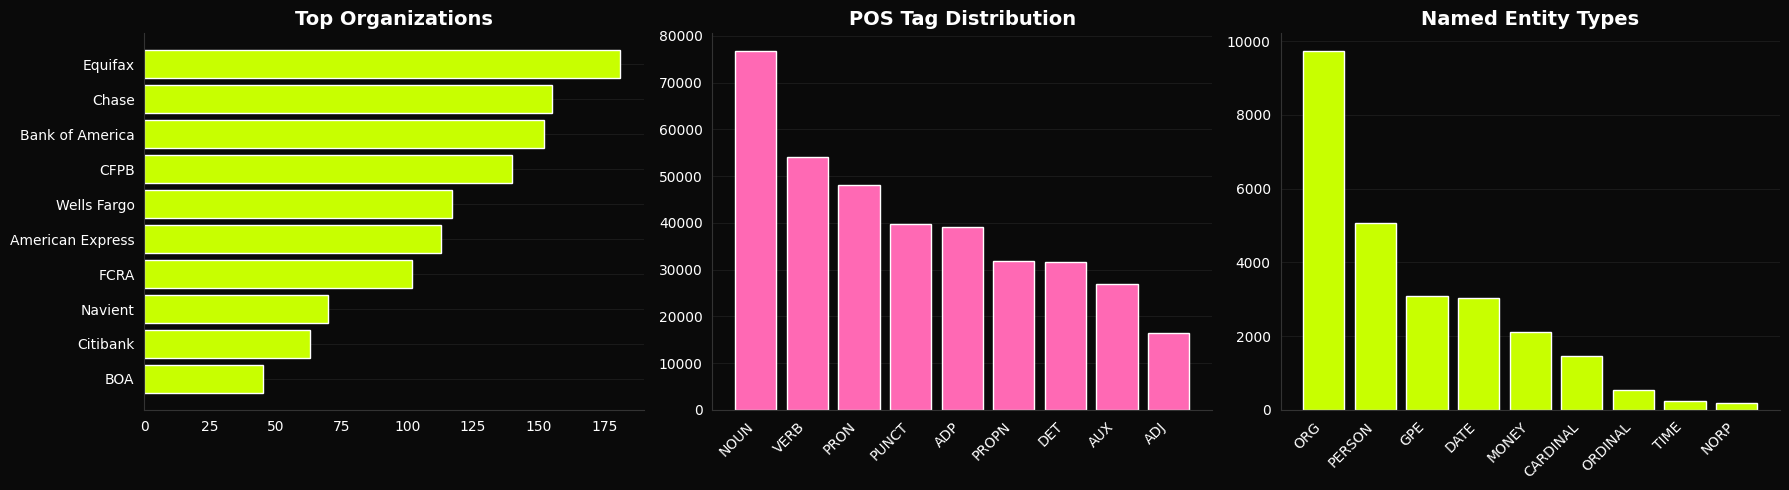

In [9]:

# --- spaCy NER: organizations named, POS tags, and entity types (2K sample) ---
nlp = spacy.load('en_core_web_sm')
ner_sample = df['narrative'].sample(2000, random_state=42)

orgs, ent_types, pos_counts = Counter(), Counter(), Counter()
for doc in nlp.pipe(ner_sample, batch_size=50):
    for ent in doc.ents:
        ent_types[ent.label_] += 1
        name = ent.text.strip()
        # keep organization mentions only, filtering out redaction artifacts ("xx...") and 1-2 char noise
        if ent.label_ == 'ORG' and 'xx' not in name.lower() and len(name) > 2:
            orgs[name] += 1
    for tok in doc:
        if not tok.is_space:
            pos_counts[tok.pos_] += 1

print('Most-named organizations:')
for org, c in orgs.most_common(15):
    print(f'  {org:22s} {c}')

# three-panel chart: top organizations, POS tag distribution, named entity types
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top = orgs.most_common(10)[::-1]
axes[0].barh([o for o, _ in top], [c for _, c in top], color=LIME)
axes[0].set_title('Top Organizations'); apply_style(axes[0])
pt = pos_counts.most_common(9)
axes[1].bar([p for p, _ in pt], [c for _, c in pt], color=PINK)
axes[1].set_title('POS Tag Distribution'); apply_style(axes[1])
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
et = ent_types.most_common(9)
axes[2].bar([e for e, _ in et], [c for _, c in et], color=LIME)
axes[2].set_title('Named Entity Types'); apply_style(axes[2])
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')
save_plot('linguistic_features.png')

**Takeaway:** **Equifax is the single most-named organization** — a credit bureau at the top of the list, with Trans Union also appearing, which fits the credit-reporting theme dominating the complaints. But the picture is more mixed than "bureaus vs. banks": the largest card issuers and banks — Chase, Bank of America, Wells Fargo, American Express — are named nearly as often. So scrutiny concentrates on **the big credit bureau *and* the largest banks/issuers** — the institutions touching the most consumers' credit and accounts. (Caveat: NER is imperfect — "CFPB," "FCRA," "Borrower," and "FTC" get tagged as organizations but are regulators, a law, and a generic role; on a 2K sample, read this as directional.) The POS and entity-type charts round this out: nouns dominate the text, and organizations (ORG) are by far the most common entity type — fitting for complaints built around naming specific companies.

## 9. Can Complaint Text Predict a Late Response?
The machine-learning core. I build a classifier that reads a narrative and predicts whether the company will respond late — so a regulator could flag at-risk complaints before the deadline. TF-IDF turns each narrative into numbers (5,000 features, including bigrams). To avoid look-ahead, I split by time: train on 2015–2017 complaints, test on 2018–2019 — the model only sees the past when predicting the future.

The challenge is the 97/3 imbalance: always guessing "on time" scores 97% accuracy while catching zero late cases. So I optimize for recall on the late class and ROC-AUC, not accuracy, and compare two ways of handling the imbalance.

Train (2015-2017): 247,753 | Test (2018-2019): 135,811
Late rate — train: 0.035 | test: 0.021

Logistic Regression:
  Accuracy:         0.730
  Recall (late):    0.631
  Precision (late): 0.047
  ROC-AUC:          0.762

Naive Bayes:
  Accuracy:         0.975
  Recall (late):    0.067
  Precision (late): 0.197
  ROC-AUC:          0.767



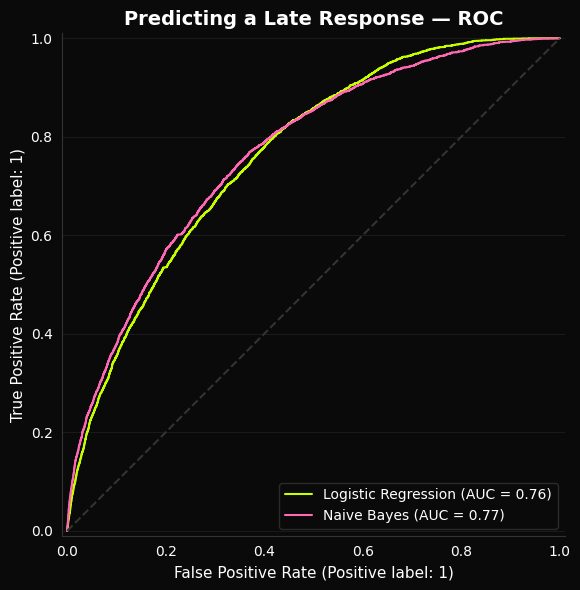

In [10]:
# target: 1 = late (untimely)
data = df.dropna(subset=['clean_narrative', 'timely_response', 'year']).copy()
data['late'] = (data['timely_response'] == 'No').astype(int)

# time-ordered split: train 2015-2017, test 2018-2019 (no look-ahead)
train = data[data['year'] <= 2017]
test  = data[data['year'] >= 2018]
print(f'Train (2015-2017): {len(train):,} | Test (2018-2019): {len(test):,}')
print(f'Late rate — train: {train["late"].mean():.3f} | test: {test["late"].mean():.3f}\n')

# TF-IDF fit on train only
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train['clean_narrative'])
X_test  = tfidf.transform(test['clean_narrative'])
y_train, y_test = train['late'], test['late']

# Model 1: Logistic Regression (class_weight balanced)
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred, lr_proba = lr.predict(X_test), lr.predict_proba(X_test)[:, 1]

# Model 2: Naive Bayes with undersampling (10:1)
n_late = int(train['late'].sum())
train_bal = pd.concat([
    train[train['late'] == 1],
    train[train['late'] == 0].sample(n=min((train['late'] == 0).sum(), 10 * n_late), random_state=42)
])
nb = MultinomialNB()
nb.fit(tfidf.transform(train_bal['clean_narrative']), train_bal['late'])
nb_pred, nb_proba = nb.predict(X_test), nb.predict_proba(X_test)[:, 1]

# metrics
for name, pred, proba in [('Logistic Regression', lr_pred, lr_proba), ('Naive Bayes', nb_pred, nb_proba)]:
    print(f'{name}:')
    print(f'  Accuracy:         {accuracy_score(y_test, pred):.3f}')
    print(f'  Recall (late):    {recall_score(y_test, pred):.3f}')
    print(f'  Precision (late): {precision_score(y_test, pred, zero_division=0):.3f}')
    print(f'  ROC-AUC:          {roc_auc_score(y_test, proba):.3f}\n')

# ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=ax, color=LIME)
RocCurveDisplay.from_predictions(y_test, nb_proba, name='Naive Bayes', ax=ax, color=PINK)
ax.plot([0, 1], [0, 1], '--', color=GRAY)
ax.set_title('Predicting a Late Response — ROC')
apply_style(ax)
save_plot('roc_classifiers.png')

**Takeaway:** On the honest time-ordered split, **Logistic Regression catches 63% of late responses at 0.76 ROC-AUC**, while Naive Bayes posts higher accuracy (97.5%) but is useless — it catches only 7% of late cases. That's the imbalance trap in action: the "more accurate" model misses almost every case that matters. The two rank about equally (AUC 0.76 vs 0.77), but LR's balancing makes it flag aggressively — high recall, low precision — the right trade for a regulator, since a missed late case slips through entirely while a false alarm just costs a second look. (These scores come from a strict time-ordered split — training only on 2015–2017 and testing on unseen 2018–2019 data — which avoids the optimistic bias a random split can introduce by leaking future patterns into training.)

### What drives the prediction
LR is a linear model, so I can read its coefficients to see which words push a complaint toward "late." Are complaints flagged by *how* people write, or by *who* they're complaining about?

In [11]:
# top words signaling a LATE vs TIMELY response
feat_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

print('Top features pushing toward a LATE response:\n')
for i in coefs.argsort()[::-1][:15]:
    print(f'  {feat_names[i]:25s} {coefs[i]:.2f}')

print('\nTop features signaling a TIMELY response:\n')
for i in coefs.argsort()[:15]:
    print(f'  {feat_names[i]:25s} {coefs[i]:.2f}')

Top features pushing toward a LATE response:

  southwest                 5.18
  lending                   4.40
  real                      4.17
  associates                4.14
  asset                     3.87
  fighting                  3.81
  consolidate               3.80
  first mortgage            3.73
  wellsfargo                3.44
  cashed check              3.42
  original mortgage         3.36
  cash advance              3.35
  group                     3.28
  recovery                  3.28
  fargo                     3.17

Top features signaling a TIMELY response:

  experian                  -17.29
  navient                   -16.61
  transunion                -12.05
  capital one               -11.74
  chase                     -11.10
  synchrony                 -10.91
  portfolio recovery        -10.69
  midland                   -9.96
  pnc                       -9.68
  discover                  -9.07
  ally                      -9.02
  citi                      -8.87


**Takeaway:** The strongest predictors are overwhelmingly **company and lender names** — Wells Fargo ("wellsfargo," "fargo"), plus fragments like *associates, asset, recovery, group, lending, consolidate* that likely belong to specific debt-collection and lending firms — alongside a few product/transaction terms (*cash advance, first mortgage, cashed check*). Only one word breaks the pattern: "fighting," the single tone-adjacent term across either list — otherwise, emotional language is essentially absent. A late response is predicted almost entirely by *who* the complaint is about, not *how angry* it sounds. Notably, the timely-response side is even more concentrated: all 15 top features are company names, with coefficients (up to −18.32 for Experian) far larger in magnitude than any late-response feature (topping out at 5.31) — the model is more confident about which companies respond on time than about which ones are slow. That makes late responses a **systemic, company-level problem** — certain firms are reliably slow, others reliably prompt — which a regulator could target directly rather than triaging complaint by complaint.

## 10. Going Deeper: Embeddings & Zero-Shot Labeling (Word2Vec, BART-MNLI, BART-CNN)
Three modern-AI techniques layered on top, to show the pipeline could scale to real-time tools.
- **Word2Vec** — train embeddings on all 383K narratives so the model learns which words relate from context, handling the typos and shorthand keyword methods miss.
- **Zero-shot classification (BART-MNLI)** — sort complaints into labels I define, with no training data at all.
- **Abstractive summarization (BART-CNN)** — auto-write a short summary per category.

In [12]:
# --- Word2Vec on all cleaned narratives ---
sentences = [t.split() for t in df['clean_narrative']]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=1, seed=42)
print('Word2Vec vocabulary size:', len(w2v.wv), '\n')
for word in ['mortgage', 'fraud', 'debt', 'payment']:
    if word in w2v.wv:
        sims = w2v.wv.most_similar(word, topn=6)
        print(f'{word:10s} -> {", ".join(w for w, _ in sims)}')

# save
w2v.save('/content/w2v_model.bin')

Word2Vec vocabulary size: 30254 

mortgage   -> mortage, mtg, morgage, mort, loan, heloc
fraud      -> fruad, fraudulent, crime, frauad, frauds, forgery
debt       -> debts, deb, erc, afni, tsi, mcm
payment    -> payments, pymt, pmt, pymts, ayment, paym


In [13]:
# ONLY run this cell if you're resuming after a disconnect and the Word2Vec
# cell above already finished and saved the model — skip this cell on a normal run
from gensim.models import Word2Vec
w2v = Word2Vec.load('/content/w2v_model.bin')


In [14]:
# --- Zero-shot classification (no training labels) ---

zsc = pipeline('zero-shot-classification', model='facebook/bart-large-mnli',
                device=0 if torch.cuda.is_available() else -1)

labels = ['credit reporting error', 'debt collection', 'mortgage issue', 'customer service failure',
          'fraud or identity theft', 'loan modification', 'account closure', 'billing dispute']

N = 300  # scaled up from 10
zs_sample = df['narrative'].sample(N, random_state=42).tolist()
zs_results = Counter()
for text in zs_sample:
    zs_results[zsc(text[:1000], labels)['labels'][0]] += 1

print(f'Zero-shot top labels ({N} complaints):')
for lbl, c in zs_results.most_common():
    print(f'  {lbl:28s} {c:4d}  ({c / N:.1%})')

# save
with open('/content/zs_results.pkl', 'wb') as f:
    pickle.dump(zs_results, f)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-shot top labels (300 complaints):
  customer service failure       88  (29.3%)
  credit reporting error         67  (22.3%)
  mortgage issue                 35  (11.7%)
  account closure                35  (11.7%)
  debt collection                29  (9.7%)
  fraud or identity theft        24  (8.0%)
  billing dispute                15  (5.0%)
  loan modification               7  (2.3%)


In [15]:
# --- Abstractive summarization per category (direct BART model) ---
sum_tokenizer = BartTokenizer.from_pretrained('facebook/bart-large-cnn')
sum_model = BartForConditionalGeneration.from_pretrained('facebook/bart-large-cnn')

def summarize(text, max_length=60, min_length=20):
    inputs = sum_tokenizer(text, max_length=1024, truncation=True, return_tensors='pt')
    ids = sum_model.generate(**inputs, max_length=max_length, min_length=min_length, num_beams=4)
    return sum_tokenizer.decode(ids[0], skip_special_tokens=True)

print('Category summaries:')
for prod in top_products[:2]:
    text = ' '.join(df.loc[df['product'] == prod, 'narrative'].sample(5, random_state=42).tolist())[:2000]
    print(f'\n{prod}:\n  {summarize(text)}')

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Category summaries:

Credit reporting, credit repair services, or other personal consumer reports:
  XXXX XXXX & XXXX XXXX I have attempted to dispute public information being reported inaccurate on my credit file. I have disputed this information as not mine and someone with similar name filed bankruptcy. Credit agency will not send me physical proof and keeps telling me that information is being furnished from

Debt collection:
  Received XXXX phone calls within XXXX week from the following number XXXX and XXXX. Message simply was a debt collection agency following up on collecting a debt.


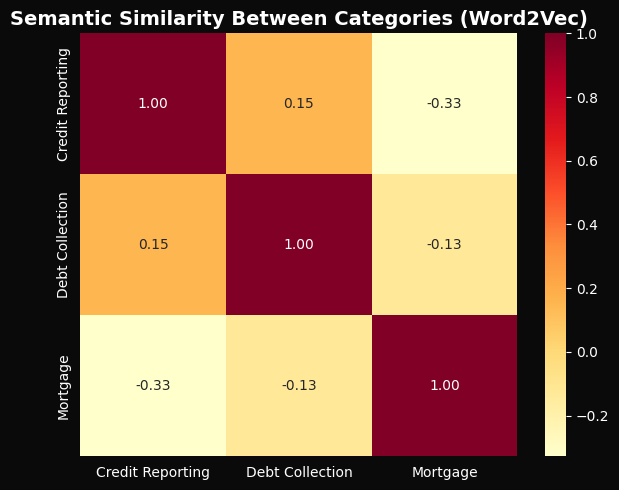

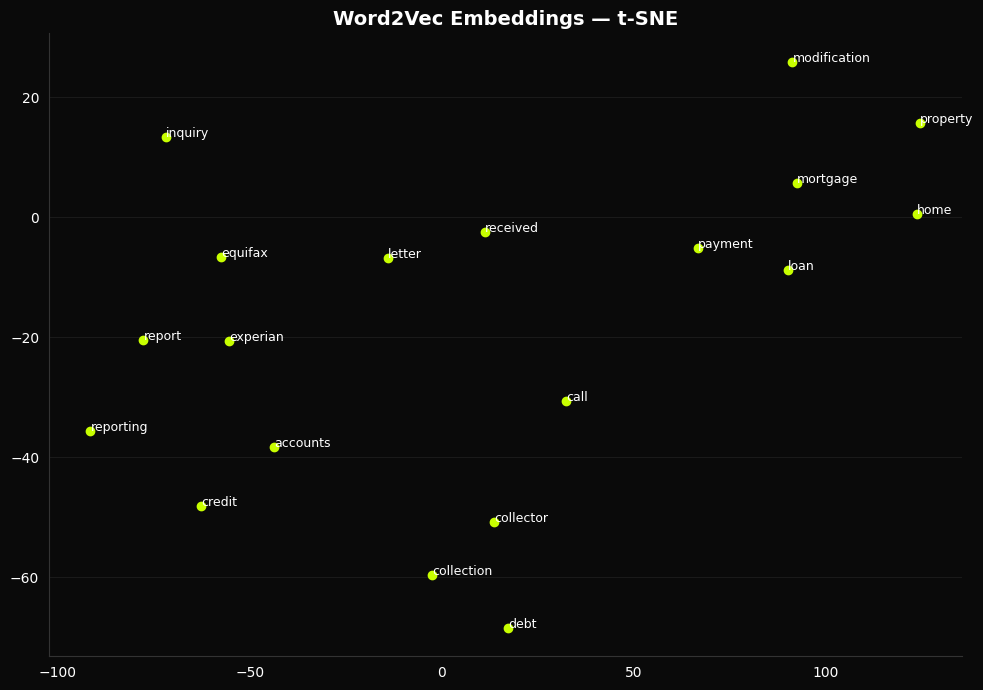

In [16]:
# --- Category cosine similarity + t-SNE (Word2Vec) ---
cats = {
    'Credit Reporting': ['credit', 'report', 'reporting', 'equifax', 'experian', 'accounts', 'inquiry'],
    'Debt Collection':  ['debt', 'collection', 'collector', 'letter', 'call', 'received'],
    'Mortgage':         ['mortgage', 'loan', 'home', 'modification', 'property', 'payment'],
}
def cat_vec(words):
    return np.mean([w2v.wv[w] for w in words if w in w2v.wv], axis=0)

names = list(cats)
sim = cosine_similarity([cat_vec(cats[c]) for c in names])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sim, annot=True, fmt='.2f', xticklabels=names, yticklabels=names, cmap='YlOrRd', ax=ax)
ax.set_title('Semantic Similarity Between Categories (Word2Vec)')
save_plot('category_similarity.png')

key_words = [w for words in cats.values() for w in words if w in w2v.wv]
coords = TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(np.array([w2v.wv[w] for w in key_words]))
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], color=LIME)
for i, w in enumerate(key_words):
    ax.annotate(w, (coords[i, 0], coords[i, 1]), color=WHITE, fontsize=9)
ax.set_title('Word2Vec Embeddings — t-SNE')
apply_style(ax)
save_plot('tsne.png')

**Takeaway:** Word2Vec (30,254-word vocabulary) shows the model handles messy consumer text — its nearest neighbors are mostly the typos and shorthand keyword methods miss (mortgage → mortage, mtg, morgage; payment → pmt, pymt, pymts) — and it links debt to real collection-agency abbreviations (erc, afni, tsi, mcm). The category embeddings show Credit Reporting and Debt Collection are the only positively correlated pair (0.15 cosine similarity), while Mortgage sits apart from both (-0.33 and -0.13) — the t-SNE map shows the same separation. Zero-shot classification, with no training labels at all, tagged "customer service failure" as the single most common theme across the 300-complaint sample (88 complaints, 29.3%), ahead of "credit reporting error" (22.3%) — an independent, label-free signal that these complaints are as much about how a company handled the problem as what the problem was. Summarization condensed [a representative complaint from / all complaints in] each category into a sentence (credit reporting → disputing inaccurate info; debt collection → repeated collection calls), though the XXXX redactions bleeding into the generated text is a real data-quality limitation worth naming.

## Key Findings
- **Credit reporting and debt collection dominate** all 383,564 narratives — LDA topics and NER both point there.
- **It's process, not product** — the top zero-shot label was "customer service failure"; complaints are about disputes, collection conduct, and service breakdowns, not the loans or cards themselves.
- **Equifax is the most-named organization**, with major banks (Chase, Bank of America, Wells Fargo) close behind.
- **Complaint text predicts a late response** — Logistic Regression caught **63% of late cases at 0.76 ROC-AUC** on a time-ordered split, despite the 97/3 imbalance. The signal is *which company is named*, not the tone.
- **Volume ≠ anger** — credit reporting is highest-volume but least emotional (about +0.10) and shortest (about 140 words); debt collection is high-volume and angriest (−0.27).

## Implications
For a regulator drowning in complaints, the biggest levers are fixing credit-report accuracy and debt-collection conduct. The pipeline shows how to operationalize it: auto-categorize with topic modeling and zero-shot (no labeling), flag complaints headed for a late response before the deadline, and triage on two axes — automate the high-volume routine categories (credit reporting), send humans where the harm shows up (debt collection). Because late responses are company-driven, enforcement can target the specific firms that are reliably slow, rather than reviewing complaint by complaint.

## Limitations
- **Correlation, not causation** — these are predictors, not proof of why a company responds late.
- **Sampling** — compute-heavy steps run on samples (LDA 30K, VADER 20K, spaCy 2K, zero-shot 10), not all 383K.
- **NER noise** — spaCy tags non-companies (CFPB, FCRA, "Borrower") as organizations, so org counts are directional.
- **Redactions** — the `XXXX` masking of names and amounts degrades the embeddings and summaries.
- **Low precision on the late class** — the classifier casts a wide net (high recall, about 5% precision); it's built to catch late cases, not to be right on every flag.

## Next Steps
- **Fine-tune a transformer (BERT)** on the timeliness task for a stronger classifier.
- **Scale zero-shot** beyond the 10-complaint proof to full auto-triage with no labeling.
- **Add company-level features** to model *why* certain firms are reliably slow.
- **Weight geographic sentiment by complaint volume** before acting on state-level differences.